In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
%matplotlib inline
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

import os

In [2]:
print (os.getcwd())

C:\Users\SURAJ GHADAGE


In [3]:
os.chdir("C:\\Users\\SURAJ GHADAGE\\Downloads")
print(os.getcwd())

C:\Users\SURAJ GHADAGE\Downloads


In [4]:
df=pd.read_csv('car data.csv')
display (df)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df .describe()


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df.duplicated().sum()

np.int64(0)

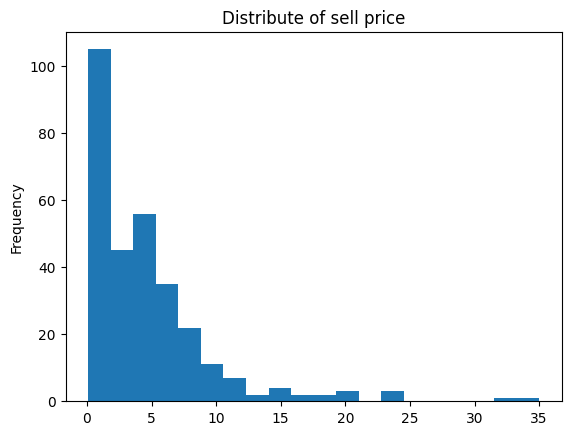

In [12]:
df["Selling_Price"].plot(kind ="hist", bins =20, title = "Distribute of sell price"
                       )
plt.show()

In [13]:
fule_type_avg_price = df.groupby("Fuel_Type")["Selling_Price"].mean()

print(fule_type_avg_price)

Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


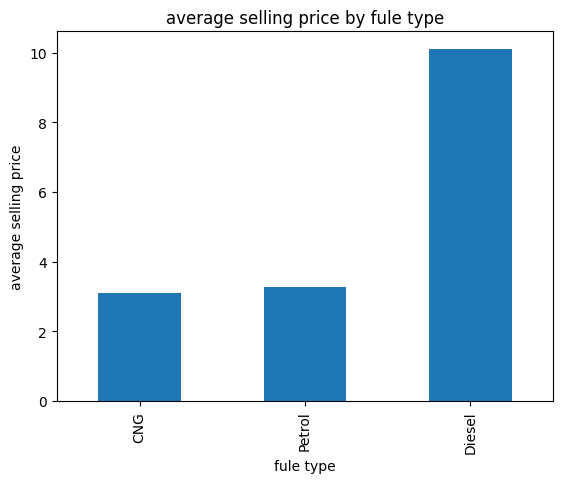

In [14]:
fule_type_avg_price.sort_values(ascending= True).plot (kind = "bar", title = "average selling price by fule type")
plt.xlabel("fule type")
plt.ylabel("average selling price")
plt.show()

In [15]:
transmission_counts = df["Transmission"].value_counts()


In [16]:
transmission_counts

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

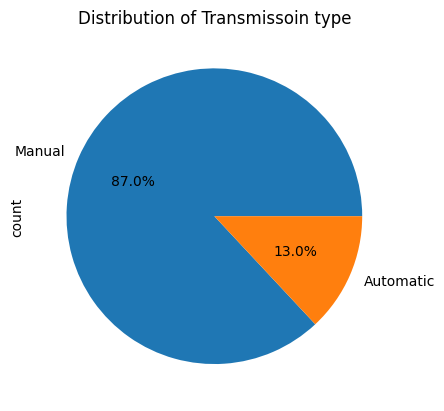

In [17]:
transmission_counts.plot(kind = "pie",autopct = "%1.1f%%",title = 'Distribution of Transmissoin type')
plt.show()

In [18]:
Selling_type_total_present_price = df.groupby("Selling_type")["Present_Price"].sum()


In [19]:
Selling_type_total_present_price 

Selling_type
Dealer        2081.43
Individual     173.34
Name: Present_Price, dtype: float64

In [20]:
yearly_avg_kms_driver = df.groupby('Year')['Driven_kms'].mean()

In [21]:
yearly_avg_kms_driver


Year
2003     94500.000000
2004    135154.000000
2005    104294.000000
2006     87422.250000
2007     51000.000000
2008    112128.571429
2009     67820.500000
2010     60014.066667
2011     40327.368421
2012     43798.217391
2013     41534.333333
2014     38080.315789
2015     31977.683333
2016     17885.040816
2017     10419.800000
2018      2071.000000
Name: Driven_kms, dtype: float64

In [22]:
Fuel_Type_max_Selling_Price = df.groupby(['Fuel_Type','Transmission'])['Selling_Price'].max()

In [23]:
Fuel_Type_max_Selling_Price

Fuel_Type  Transmission
CNG        Manual           3.25
Diesel     Automatic       33.00
           Manual          35.00
Petrol     Automatic       19.75
           Manual          17.00
Name: Selling_Price, dtype: float64

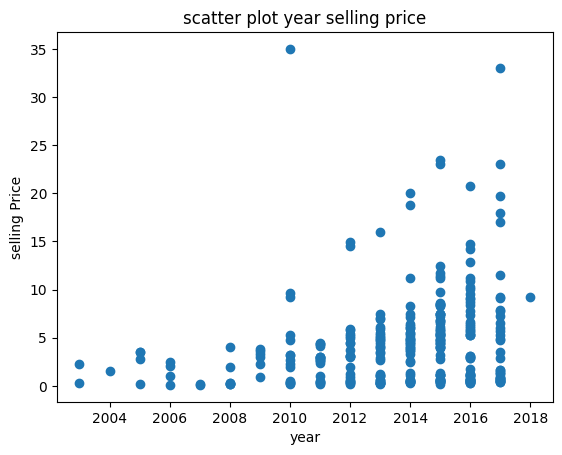

In [24]:
plt.scatter(df['Year'],df['Selling_Price'])
plt.title('scatter plot year selling price')
plt.xlabel('year')
plt.ylabel('selling Price')
plt.show()


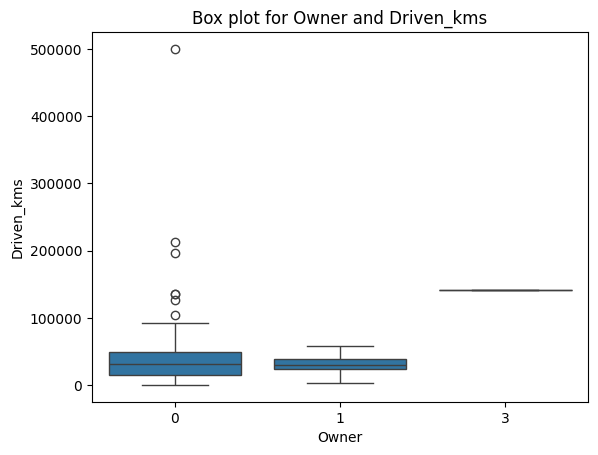

In [25]:
sns.boxplot(x='Owner', y='Driven_kms', data=df)  
plt.title('Box plot for Owner and Driven_kms')
plt.xlabel('Owner')   
plt.ylabel('Driven_kms')  
plt.show()


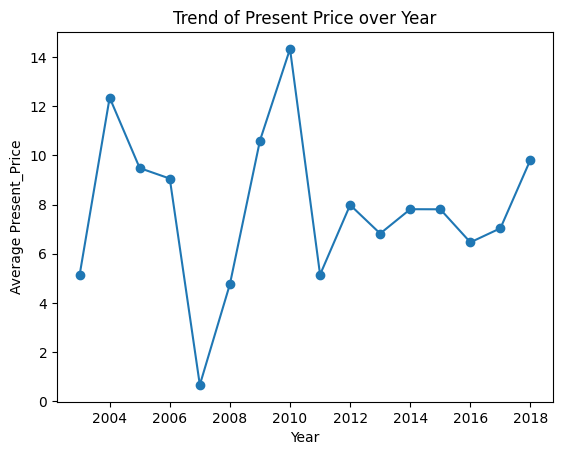

In [26]:
plt.plot(df.groupby('Year')['Present_Price'].mean(), marker='o') 
plt.title("Trend of Present Price over Year")
plt.xlabel('Year')
plt.ylabel('Average Present_Price')
plt.show()


In [29]:
avg_price =df.groupby(['Fuel_Type','Transmission'])['Selling_Price'].mean().unstack() 


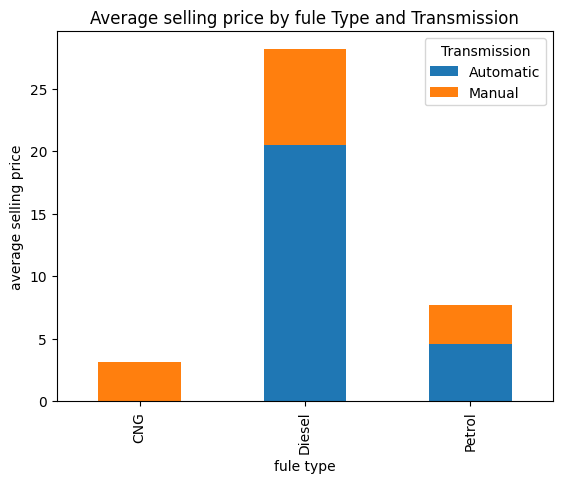

In [30]:
avg_price.plot (kind = "bar", stacked = True )
plt.title("Average selling price by fule Type and Transmission")
plt.xlabel("fule type")
plt.ylabel("average selling price")
plt.show() 

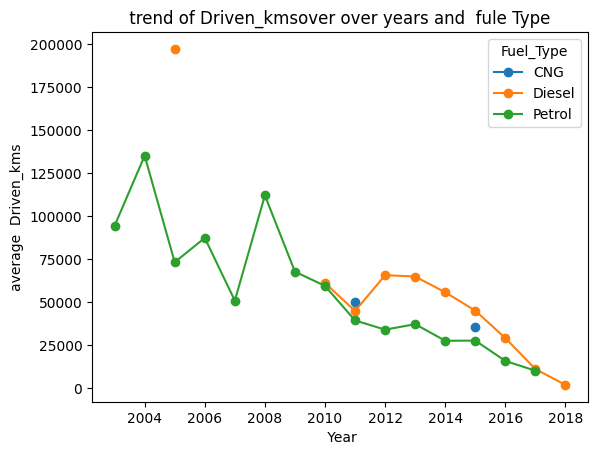

In [31]:
Trd_kmsDeive =df.groupby(['Year','Fuel_Type'])['Driven_kms'].mean().unstack() 
Trd_kmsDeive.plot (kind = "line", marker = 'o' )
plt.title(" trend of Driven_kmsover over years and  fule Type ")
plt.xlabel(" Year")
plt.ylabel("average  Driven_kms")
plt.show()

In [32]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [36]:
X = df.iloc[:,[0,1,3,4,5,6,7,8]].values
display (X)


array([['ritz', 2014, 5.59, ..., 'Dealer', 'Manual', 0],
       ['sx4', 2013, 9.54, ..., 'Dealer', 'Manual', 0],
       ['ciaz', 2017, 9.85, ..., 'Dealer', 'Manual', 0],
       ...,
       ['city', 2009, 11.0, ..., 'Dealer', 'Manual', 0],
       ['city', 2017, 12.5, ..., 'Dealer', 'Manual', 0],
       ['brio', 2016, 5.9, ..., 'Dealer', 'Manual', 0]],
      shape=(299, 8), dtype=object)

In [37]:
Y = df.iloc[:,[2]].values
display (Y)


array([[ 3.35],
       [ 4.75],
       [ 7.25],
       [ 2.85],
       [ 4.6 ],
       [ 9.25],
       [ 6.75],
       [ 6.5 ],
       [ 8.75],
       [ 7.45],
       [ 2.85],
       [ 6.85],
       [ 7.5 ],
       [ 6.1 ],
       [ 2.25],
       [ 7.75],
       [ 7.25],
       [ 3.25],
       [ 2.65],
       [ 2.85],
       [ 4.9 ],
       [ 4.4 ],
       [ 2.5 ],
       [ 2.9 ],
       [ 3.  ],
       [ 4.15],
       [ 6.  ],
       [ 1.95],
       [ 7.45],
       [ 3.1 ],
       [ 2.35],
       [ 4.95],
       [ 6.  ],
       [ 5.5 ],
       [ 2.95],
       [ 4.65],
       [ 0.35],
       [ 3.  ],
       [ 2.25],
       [ 5.85],
       [ 2.55],
       [ 1.95],
       [ 5.5 ],
       [ 1.25],
       [ 7.5 ],
       [ 2.65],
       [ 1.05],
       [ 5.8 ],
       [ 7.75],
       [14.9 ],
       [23.  ],
       [18.  ],
       [16.  ],
       [ 2.75],
       [ 3.6 ],
       [ 4.5 ],
       [ 4.75],
       [ 4.1 ],
       [19.99],
       [ 6.95],
       [ 4.5 ],
       [18.75],
       [

In [38]:
display(pd.DataFrame(X).head(5))

,0,1,2,3,4,5,6,7
0,ritz,2014,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,6.87,42450,Diesel,Dealer,Manual,0


In [39]:
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
X[:,0] = le1.fit_transform(X[:,0])
le2 = LabelEncoder()
X[:,-4] = le2.fit_transform(X[:,-4])
display (X)


array([[90, 2014, 5.59, ..., 'Dealer', 'Manual', 0],
       [93, 2013, 9.54, ..., 'Dealer', 'Manual', 0],
       [68, 2017, 9.85, ..., 'Dealer', 'Manual', 0],
       ...,
       [69, 2009, 11.0, ..., 'Dealer', 'Manual', 0],
       [69, 2017, 12.5, ..., 'Dealer', 'Manual', 0],
       [66, 2016, 5.9, ..., 'Dealer', 'Manual', 0]],
      shape=(299, 8), dtype=object)

In [46]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(sparse_output=False), [2])],
    remainder='passthrough'
)

X = ct.fit_transform(X)




In [47]:
display (pd.DataFrame(X))

,0,1,2,3,4,5,6,7,8,9,...,147,148,149,150,151,152,153,154,155,156
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,90,2014,27000,2,Dealer,Manual,0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,93,2013,43000,1,Dealer,Manual,0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,68,2017,6900,2,Dealer,Manual,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,96,2011,5200,2,Dealer,Manual,0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,92,2014,42450,1,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,69,2016,33988,1,Dealer,Manual,0
295,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,66,2015,60000,2,Dealer,Manual,0
296,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,69,2009,87934,2,Dealer,Manual,0
297,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,69,2017,9000,1,Dealer,Manual,0


In [49]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


numeric_features = ['Year', 'Present_Price', 'Driven_kms', 'Owner']
categorical_features = ['Fuel_Type', 'Selling_type', 'Transmission']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_features)
    ]
)

X = preprocessor.fit_transform(df)   
X = pd.DataFrame(X)                 
display(X)



,0,1,2,3,4,5,6,7
0,0.132992,-0.228138,-0.254603,-0.175101,0.0,1.0,0.0,1.0
1,-0.212787,0.233742,0.156181,-0.175101,1.0,0.0,0.0,1.0
2,1.170329,0.269991,-0.770651,-0.175101,0.0,1.0,0.0,1.0
3,-0.904345,-0.396520,-0.814297,-0.175101,0.0,1.0,0.0,1.0
4,0.132992,-0.078466,0.142061,-0.175101,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
294,0.824550,0.474622,-0.075193,-0.175101,1.0,0.0,0.0,1.0
295,0.478771,-0.191889,0.592640,-0.175101,0.0,1.0,0.0,1.0
296,-1.595904,0.404463,1.309818,-0.175101,0.0,1.0,0.0,1.0
297,1.170329,0.579860,-0.716735,-0.175101,1.0,0.0,0.0,1.0


In [50]:
from sklearn.model_selection import train_test_split
(X_train,X_test,Y_train,Y_test) = train_test_split(X,Y,test_size=0.2,random_state=0)



In [51]:
from sklearn.ensemble import RandomForestRegressor
regression = RandomForestRegressor(random_state=0)
regression.fit(X_train,Y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred = regression.predict(X_test)
display (y_pred)


array([ 7.0738,  0.2117,  7.0209,  3.929 ,  2.8815,  0.5962,  5.3244,
        4.2045, 14.3234,  1.083 ,  4.309 ,  7.7893,  0.2206,  2.9455,
        1.9021,  4.1505,  3.2963,  8.1953,  3.412 ,  8.8195,  0.1893,
        1.1379,  0.7518,  0.5241,  4.9955,  1.1101,  0.1813,  4.6655,
        8.8136,  5.4457,  6.3477,  9.0078,  7.6535,  1.153 ,  4.7233,
        0.5012,  0.3339,  0.2928,  5.3835,  7.955 ,  7.9465,  4.5227,
       20.1816,  3.5115,  4.602 ,  0.5788,  2.96  ,  4.3115,  6.536 ,
        2.6425,  6.6275,  3.7975,  0.3445,  1.1547,  7.1063, 10.5728,
        0.5631,  5.2315,  6.646 ,  0.4369])

In [53]:
print(np.concatenate((y_pred.reshape(len(y_pred),1),Y_test.reshape(len(Y_test),1)),1))


[[ 7.0738  7.9   ]
 [ 0.2117  0.2   ]
 [ 7.0209  7.5   ]
 [ 3.929   4.5   ]
 [ 2.8815  2.    ]
 [ 0.5962  0.6   ]
 [ 5.3244  6.15  ]
 [ 4.2045  5.15  ]
 [14.3234 16.    ]
 [ 1.083   1.2   ]
 [ 4.309   4.4   ]
 [ 7.7893  7.75  ]
 [ 0.2206  0.25  ]
 [ 2.9455  4.    ]
 [ 1.9021  2.5   ]
 [ 4.1505  3.95  ]
 [ 3.2963  3.    ]
 [ 8.1953 11.25  ]
 [ 3.412   3.1   ]
 [ 8.8195  8.5   ]
 [ 0.1893  0.2   ]
 [ 1.1379  1.35  ]
 [ 0.7518  0.9   ]
 [ 0.5241  0.75  ]
 [ 4.9955  6.    ]
 [ 1.1101  1.1   ]
 [ 0.1813  0.17  ]
 [ 4.6655  5.75  ]
 [ 8.8136  9.5   ]
 [ 5.4457  5.    ]
 [ 6.3477  4.    ]
 [ 9.0078  9.25  ]
 [ 7.6535  8.75  ]
 [ 1.153   0.95  ]
 [ 4.7233  4.5   ]
 [ 0.5012  0.5   ]
 [ 0.3339  0.35  ]
 [ 0.2928  0.25  ]
 [ 5.3835  5.3   ]
 [ 7.955   9.25  ]
 [ 7.9465  6.5   ]
 [ 4.5227  3.8   ]
 [20.1816 23.    ]
 [ 3.5115  2.95  ]
 [ 4.602   4.5   ]
 [ 0.5788  0.6   ]
 [ 2.96    3.1   ]
 [ 4.3115  4.75  ]
 [ 6.536   6.5   ]
 [ 2.6425  2.65  ]
 [ 6.6275  4.9   ]
 [ 3.7975  3.25  ]
 [ 0.3445  0

In [54]:
from sklearn.metrics import r2_score,mean_absolute_error
print  ('R2 Score ', r2_score(Y_test, y_pred))
print  ('Mean Absolute Error', mean_absolute_error(Y_test,y_pred))


R2 Score  0.9567001379606671
Mean Absolute Error 0.5522683333333333


In [55]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train,Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred = reg.predict(X_test)
display (y_pred)


array([[ 6.55693448],
       [-1.97619162],
       [ 7.88549909],
       [ 5.54891442],
       [ 3.00875056],
       [ 1.42801641],
       [ 6.95269063],
       [ 5.6257047 ],
       [14.40412815],
       [ 2.00857133],
       [ 4.59889278],
       [ 8.52065693],
       [ 0.66357916],
       [ 3.2626839 ],
       [ 2.76065639],
       [ 4.71959047],
       [ 3.6147487 ],
       [ 9.92955173],
       [ 5.35747553],
       [ 7.61829004],
       [-2.96236525],
       [ 1.64605841],
       [ 2.04448188],
       [ 1.03991562],
       [ 5.81190424],
       [ 1.16441804],
       [-9.56132571],
       [ 6.23094109],
       [ 9.05754641],
       [ 5.05274747],
       [ 9.89419131],
       [10.60539113],
       [ 8.14350117],
       [ 0.66153421],
       [ 4.9437279 ],
       [ 0.29767543],
       [ 1.94716559],
       [-2.19398862],
       [ 5.244366  ],
       [ 9.53391983],
       [ 6.46309508],
       [ 7.54720596],
       [17.16487663],
       [ 2.89870184],
       [ 4.834767  ],
       [ 1

In [57]:

print(np.concatenate((y_pred.reshape(len(y_pred),1),Y_test.reshape(len(Y_test),1)),1))



[[ 6.55693448  7.9       ]
 [-1.97619162  0.2       ]
 [ 7.88549909  7.5       ]
 [ 5.54891442  4.5       ]
 [ 3.00875056  2.        ]
 [ 1.42801641  0.6       ]
 [ 6.95269063  6.15      ]
 [ 5.6257047   5.15      ]
 [14.40412815 16.        ]
 [ 2.00857133  1.2       ]
 [ 4.59889278  4.4       ]
 [ 8.52065693  7.75      ]
 [ 0.66357916  0.25      ]
 [ 3.2626839   4.        ]
 [ 2.76065639  2.5       ]
 [ 4.71959047  3.95      ]
 [ 3.6147487   3.        ]
 [ 9.92955173 11.25      ]
 [ 5.35747553  3.1       ]
 [ 7.61829004  8.5       ]
 [-2.96236525  0.2       ]
 [ 1.64605841  1.35      ]
 [ 2.04448188  0.9       ]
 [ 1.03991562  0.75      ]
 [ 5.81190424  6.        ]
 [ 1.16441804  1.1       ]
 [-9.56132571  0.17      ]
 [ 6.23094109  5.75      ]
 [ 9.05754641  9.5       ]
 [ 5.05274747  5.        ]
 [ 9.89419131  4.        ]
 [10.60539113  9.25      ]
 [ 8.14350117  8.75      ]
 [ 0.66153421  0.95      ]
 [ 4.9437279   4.5       ]
 [ 0.29767543  0.5       ]
 [ 1.94716559  0.35      ]
 

In [58]:
from sklearn.metrics import r2_score,mean_absolute_error
print  ('R2 Score ', r2_score(Y_test, y_pred))
print  ('Mean Absolute Error', mean_absolute_error(Y_test,y_pred))



R2 Score  0.7581011893945309
Mean Absolute Error 1.2562526157504272


In [59]:
y_pred = reg.predict(X)
display (y_pred)


array([[ 4.06350849e+00],
       [ 7.05438306e+00],
       [ 7.25561704e+00],
       [ 2.95224159e+00],
       [ 6.19894615e+00],
       [ 9.53391983e+00],
       [ 5.64515765e+00],
       [ 7.45016276e+00],
       [ 8.14350117e+00],
       [ 7.40651756e+00],
       [ 4.60727396e+00],
       [ 7.87393440e+00],
       [ 7.88549909e+00],
       [ 5.32025685e+00],
       [ 2.23157269e+00],
       [ 8.52065693e+00],
       [ 8.24143128e+00],
       [ 3.25000000e+00],
       [ 3.59917893e+00],
       [ 3.99528612e+00],
       [ 5.52837763e+00],
       [ 5.11094489e+00],
       [ 2.76065639e+00],
       [ 2.63868501e+00],
       [ 3.02340897e+00],
       [ 3.31473816e+00],
       [ 4.17725711e+00],
       [ 1.76738987e+00],
       [ 7.99460317e+00],
       [ 5.01576779e+00],
       [ 2.29169018e+00],
       [ 6.54055278e+00],
       [ 7.49999097e+00],
       [ 6.67015270e+00],
       [ 2.89870184e+00],
       [ 4.63845458e+00],
       [-4.18095078e+00],
       [ 4.21194635e+00],
       [ 1.0

In [60]:
result = pd.concat([df,pd.DataFrame(y_pred)],axis=1)
display( result)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,0
0,ritz,2014.0,3.35,5.59,27000.0,Petrol,Dealer,Manual,0.0,4.063508
1,sx4,2013.0,4.75,9.54,43000.0,Diesel,Dealer,Manual,0.0,7.054383
2,ciaz,2017.0,7.25,9.85,6900.0,Petrol,Dealer,Manual,0.0,7.255617
3,wagon r,2011.0,2.85,4.15,5200.0,Petrol,Dealer,Manual,0.0,2.952242
4,swift,2014.0,4.60,6.87,42450.0,Diesel,Dealer,Manual,0.0,6.198946
...,...,...,...,...,...,...,...,...,...,...
298,city,2009.0,3.35,11.00,87934.0,Petrol,Dealer,Manual,0.0,5.244366
299,city,2017.0,11.50,12.50,9000.0,Diesel,Dealer,Manual,0.0,NaN
300,brio,2016.0,5.30,5.90,5464.0,Petrol,Dealer,Manual,0.0,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.250000
